# Customer Churn Prediction and Analysis

Objective
The objective of this project is to analyze telecom customer data and identify key factors influencing customer churn. Additionally, we build a machine learning model to predict churn and provide business recommendations.


# 1. Import Required Libraries


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 2. Load Dataset


In [70]:
df = pd.read_excel('Telco_customer_churn.xlsx')
print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [71]:
per=df['Churn Value'].value_counts(normalize=True)*100
print(per)

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [72]:
df.groupby('Churn Value')['Tenure Months'].mean()

Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64

In [73]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

print(df['Total Charges'])

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64


In [74]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [75]:
df = df.dropna(subset=['Total Charges'])

In [76]:
df.shape


(7032, 33)

In [77]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')


In [78]:
df['Total Charges'].isnull().sum()

np.int64(0)

# 3. Data Cleaning

In this section:
- Converted Total Charges to numeric
- Removed missing values
- Dropped irrelevant and leakage columns
- Prepared dataset for analysis


In [79]:
df = df.drop(columns=[
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
])
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.dropna(subset=['Total Charges'])


In [80]:
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']
X = pd.get_dummies(X, drop_first=True)
X.shape

(7032, 30)

In [81]:
print(df.groupby('Contract')['Churn Value'].mean())

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn Value, dtype: float64


In [82]:
print(df.groupby('Churn Value')['Tenure Months'].median())

Churn Value
0    38.0
1    10.0
Name: Tenure Months, dtype: float64


## 4. Exploratory Data Analysis (EDA)

In this section, we analyze key factors influencing customer churn.

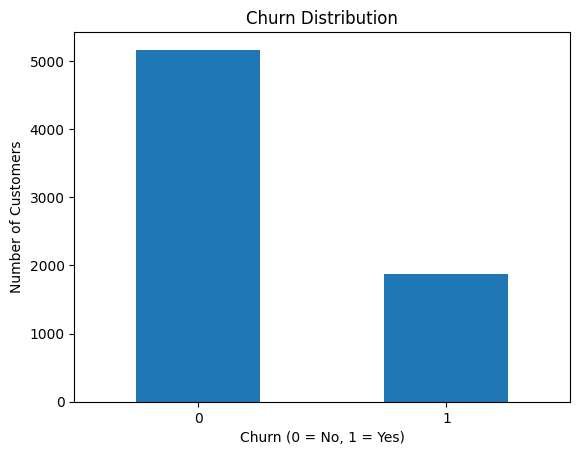

In [83]:
df['Churn Value'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

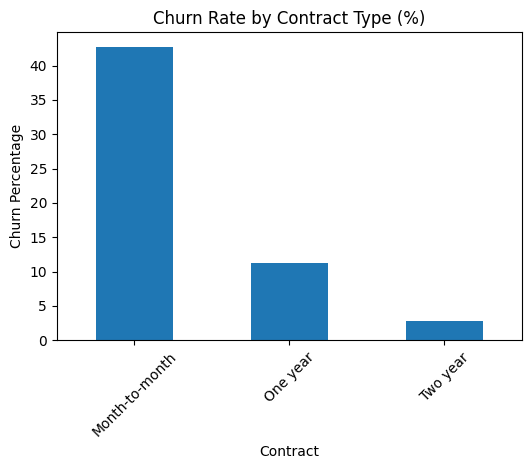

In [84]:
contract_churn = df.groupby('Contract')['Churn Value'].mean() * 100
plt.figure(figsize=(6,4))
contract_churn.plot(kind='bar')
plt.title('Churn Rate by Contract Type (%)')
plt.ylabel('Churn Percentage')
plt.xticks(rotation=45)
plt.show()

<Figure size 600x400 with 0 Axes>

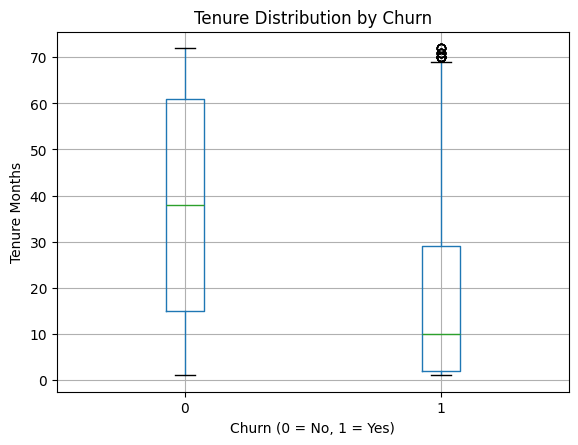

In [85]:
plt.figure(figsize=(6,4))
df.boxplot(column='Tenure Months', by='Churn Value')
plt.title('Tenure Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure Months')
plt.show()

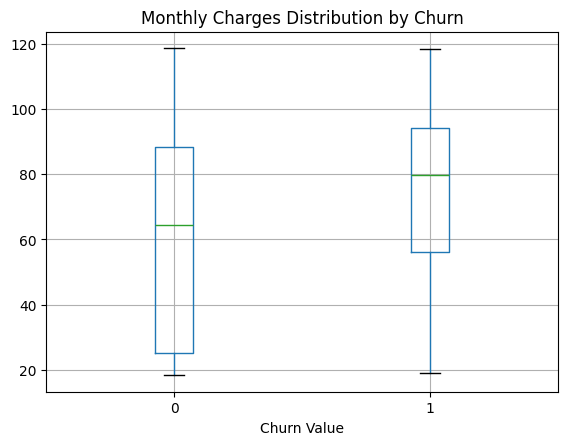

In [86]:
df.boxplot(column='Monthly Charges', by='Churn Value')
plt.title('Monthly Charges Distribution by Churn')
plt.suptitle('') # Removes the automatic subtitle
plt.show()

## 5. Model Building

In this section, we build a machine learning model to predict customer churn.

We use Logistic Regression as a baseline model since:
- The problem is binary classification (Churn = 0 or 1)
- Logistic Regression is interpretable
- It provides insights into feature influence

We also apply class balancing techniques to improve churn detection.

# 5.1 Train-Test Split

We split the dataset into:
- 80% training data
- 20% testing data

This ensures the model is evaluated on unseen data.


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [88]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


### 5.2 Logistic Regression (Baseline Model)

We first train a standard Logistic Regression model to establish a performance baseline.

In [89]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8123667377398721
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



The baseline model achieves good overall accuracy. 
However, recall for churn customers is relatively low, meaning the model misses many customers who actually churn.

Since identifying churn customers is the primary business objective, we need to improve recall.

### 5.3 Feature Scaling

Logistic Regression performs better when numerical features are scaled. 
We standardize the features to improve model convergence and performance.

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5.4 Balanced Logistic Regression

Since the dataset is moderately imbalanced, we apply class_weight='balanced' 
to improve the model's ability to detect churn customers.

In [92]:
model_balanced = LogisticRegression(max_iter=2000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7569296375266524
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1012
           1       0.54      0.82      0.65       395

    accuracy                           0.76      1407
   macro avg       0.73      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407



## 6. Model Evaluation

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Recall for churn (class 1) is particularly important, as the business goal is to correctly identify customers who are likely to leave.

In [94]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7569296375266524
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1012
           1       0.54      0.82      0.65       395

    accuracy                           0.76      1407
   macro avg       0.73      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407



### Model Performance Summary

The balanced logistic regression model achieved:

- Accuracy: ~76%
- Recall for churn: ~82%

Although overall accuracy slightly decreased compared to the baseline model, 
recall for churn improved significantly.

This means the model is better at identifying customers at risk of churning, 
which is more valuable from a business perspective.

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(max_iter=2000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

In [97]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7569296375266524
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1012
           1       0.54      0.82      0.65       395

    accuracy                           0.76      1407
   macro avg       0.73      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407



### Key Drivers of Churn

The most important factors influencing churn include:

- Tenure Months (strong negative impact)
- Contract Type (long-term contracts reduce churn)
- Total Charges
- Internet Service (Fiber optic users show higher churn)
- Monthly Charges

These insights align with the findings from exploratory data analysis.

### Extracting Model Coefficients

Before creating a feature importance DataFrame, we need to extract the

logistic regression coefficients and corresponding feature names from the
trained model.

In [98]:

coefficients = model_balanced.coef_[0]
feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

In [99]:
feature_importance.head(10)

,Feature,Coefficient
2,Total Charges,0.713180
10,Internet Service_Fiber optic,0.250052
26,Paperless Billing_Yes,0.189004
5,Partner_Yes,0.147689
28,Payment Method_Electronic check,0.138855
1,Monthly Charges,0.105430
9,Multiple Lines_Yes,0.081600
8,Multiple Lines_No phone service,0.077766
23,Streaming Movies_Yes,0.073243
4,Senior Citizen_Yes,0.050901


In [100]:
feature_importance.tail(10)

,Feature,Coefficient
16,Device Protection_No internet service,-0.041916
27,Payment Method_Credit card (automatic),-0.063968
15,Online Backup_Yes,-0.069822
7,Phone Service_Yes,-0.077766
19,Tech Support_Yes,-0.137606
13,Online Security_Yes,-0.186401
24,Contract_One year,-0.283819
25,Contract_Two year,-0.631038
6,Dependents_Yes,-0.635456
0,Tenure Months,-1.419780


## 7. Feature Importance

We analyze the coefficients of the logistic regression model to identify 
the most important factors influencing churn.

- Positive coefficients increase churn probability.
- Negative coefficients decrease churn probability.

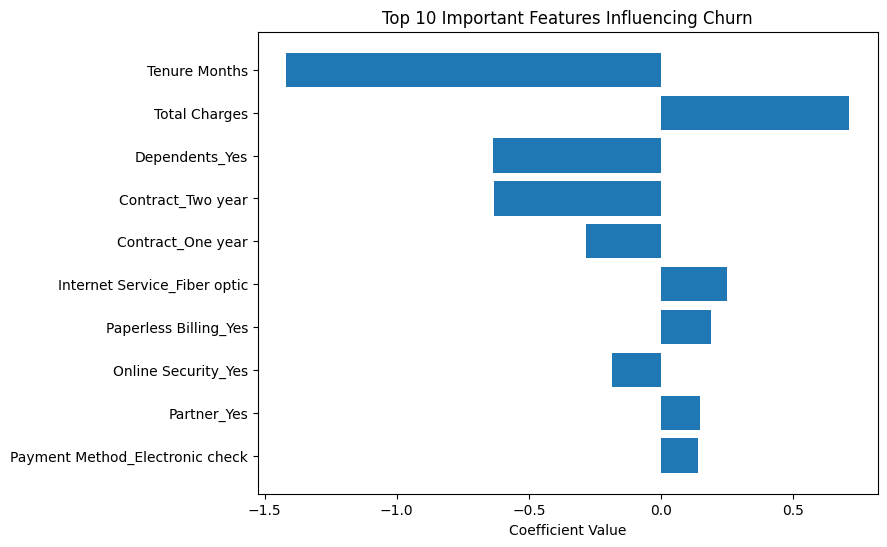

In [101]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_balanced.coef_[0]
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)
plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.title('Top 10 Important Features Influencing Churn')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()

The most influential factors affecting churn include:

- Tenure Months (strong negative impact)
- Long-term contracts significantly reduce churn
- Higher monthly charges increase churn probability
- Fiber optic users show higher churn

These findings align with insights observed during exploratory data analysis.